# Notebook 07: Size scaling (K2N) vs. single N2K operating point (SQ3)

Research Sub-Question 3: Does the cross-population directional (a)symmetry depend on source training-set size?

N2K trains on ~128 images per fold (190 Togunwa images minus the 30-image holdout, under 5-fold CV), not 190

190 is only the raw pre-holdout pool size. Because N2K exists at a single training-size operating point, this is NOT a factorial size x direction interaction test; it is a comparison of the K2N scaling curve (50/100/190) against one N2K value. Treated explicitly as such below.

## 1. Setup and load predictions

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

import sys
from pathlib import Path

REPO_ON_DRIVE = "/content/drive/MyDrive/MSc AI DISSERTATION/crosspop-cxr-asymmetry"
for candidate in [REPO_ON_DRIVE, "..", "."]:
    p = Path(candidate).resolve()
    if (p / "config.py").exists():
        sys.path.insert(0, str(p))
        break

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
from src import metrics as MET
from src import stats as ST
from src import results as RES

for mod in (config, MET, ST, RES):
    importlib.reload(mod)

config.ensure_output_dirs()
config.set_plot_style()

ext_summary = pd.read_csv(config.RESULTS_DIR / "04_inference_summary_extended.csv")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
n2k_actual_pool = config.TOGUNWA_HOLDOUT_SIZE  # 30, removed before folding
n2k_working_pool = 190 - n2k_actual_pool        # ~160
n2k_train_per_fold = round(n2k_working_pool * (config.N_FOLDS - 1) / config.N_FOLDS)

print("--- K2N scaling curve vs. N2K single operating point ---")
print(f"N2K actual training images per fold: ~{n2k_train_per_fold} "
      f"(NOT 190; 190 is the raw Togunwa pool size before the 30-image holdout is removed)")
print("N2K has only one training-size operating point, so what follows is a K2N")
print("scaling curve set against a flat N2K reference value, not a 2-way interaction.")


--- K2N scaling curve vs. N2K single operating point ---
N2K actual training images per fold: ~128 (NOT 190; 190 is the raw Togunwa pool size before the 30-image holdout is removed)
N2K has only one training-size operating point, so what follows is a K2N
scaling curve set against a flat N2K reference value, not a 2-way interaction.


## 2. K2N AUROC and ECE across matched sizes, per architecture (run-level bootstrap)

In [4]:
size_rows = []
for arch in config.ARCHITECTURES:
    for size in config.MATCHED_SIZES:
        sub = ext_summary[(ext_summary.condition == "K2N") & (ext_summary.arch == arch) & (ext_summary["size"] == size)]
        auroc_mean, auroc_lo, auroc_hi, _ = ST.run_level_bootstrap_ci(sub["auroc"].values, seed=config.SEED)
        ece_mean, ece_lo, ece_hi, _ = ST.run_level_bootstrap_ci(sub["ece"].values, seed=config.SEED)
        size_rows.append({
            "arch": arch, "size": size, "n_runs": len(sub),
            "auroc": round(auroc_mean, 3), "auroc_lo": round(auroc_lo, 3), "auroc_hi": round(auroc_hi, 3),
            "ece": round(ece_mean, 3), "ece_lo": round(ece_lo, 3), "ece_hi": round(ece_hi, 3),
        })
    # N2K reference point (flat, single size)
    sub_n2k = ext_summary[(ext_summary.condition == "N2K") & (ext_summary.arch == arch)]
    auroc_mean, auroc_lo, auroc_hi, _ = ST.run_level_bootstrap_ci(sub_n2k["auroc"].values, seed=config.SEED)
    ece_mean, ece_lo, ece_hi, _ = ST.run_level_bootstrap_ci(sub_n2k["ece"].values, seed=config.SEED)
    size_rows.append({
        "arch": arch, "size": f"N2K_ref(~{n2k_train_per_fold}/fold)", "n_runs": len(sub_n2k),
        "auroc": round(auroc_mean, 3), "auroc_lo": round(auroc_lo, 3), "auroc_hi": round(auroc_hi, 3),
        "ece": round(ece_mean, 3), "ece_lo": round(ece_lo, 3), "ece_hi": round(ece_hi, 3),
    })

size_table = pd.DataFrame(size_rows)
print(size_table.to_string(index=False))
size_table.to_csv(config.RESULTS_DIR / "07_size_scaling.csv", index=False)


           arch               size  n_runs  auroc  auroc_lo  auroc_hi   ece  ece_lo  ece_hi
   mobilenet_v2                 50       3  0.639     0.582     0.751 0.236   0.207   0.271
   mobilenet_v2                100       3  0.650     0.582     0.742 0.352   0.331   0.363
   mobilenet_v2                190       3  0.644     0.524     0.813 0.292   0.200   0.371
   mobilenet_v2 N2K_ref(~128/fold)      15  0.590     0.495     0.676 0.191   0.142   0.235
efficientnet_b0                 50       3  0.587     0.507     0.720 0.234   0.091   0.307
efficientnet_b0                100       3  0.618     0.498     0.769 0.292   0.208   0.342
efficientnet_b0                190       3  0.627     0.489     0.787 0.248   0.196   0.275
efficientnet_b0 N2K_ref(~128/fold)      15  0.730     0.676     0.782 0.154   0.128   0.181


## 3. Figure: K2N scaling curve vs. N2K reference, per architecture

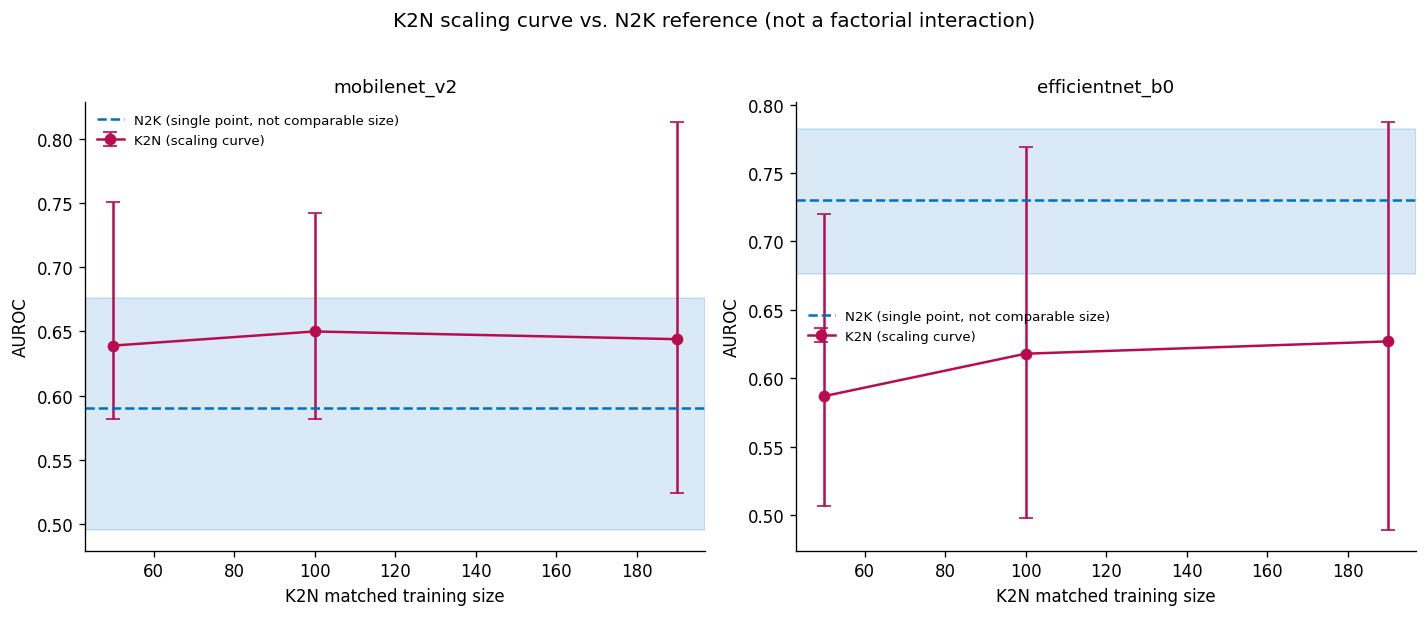

In [5]:
# Visualization: Metric vs Source Size
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, arch in zip(axes, config.ARCHITECTURES):
    curve = size_table[(size_table.arch == arch) & (size_table["size"].isin(config.MATCHED_SIZES))].sort_values("size")
    ref = size_table[(size_table.arch == arch) & (~size_table["size"].isin(config.MATCHED_SIZES))]

    yerr = [curve["auroc"] - curve["auroc_lo"], curve["auroc_hi"] - curve["auroc"]]
    ax.errorbar(curve["size"], curve["auroc"], yerr=yerr, marker="o", capsize=4,
                color=config.BRAND["C1"], label="K2N (scaling curve)")

    if len(ref) > 0:
        r = ref.iloc[0]
        ax.axhspan(r["auroc_lo"], r["auroc_hi"], alpha=0.15, color=config.BRAND["C3"])
        ax.axhline(r["auroc"], color=config.BRAND["C3"], linestyle="--", label="N2K (single point, not comparable size)")

    ax.set_xlabel("K2N matched training size")
    ax.set_ylabel("AUROC")
    ax.set_title(f"{arch}")
    ax.legend(fontsize=8)

fig.suptitle("K2N scaling curve vs. N2K reference (not a factorial interaction)", y=1.02)
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "07_size_scaling.png", dpi=120, bbox_inches="tight")
plt.show()


**Next:** notebook 08 (significance).